# Lựa chọn đặc trưng bằng SelectKBest

Notebook này thử nhiều giá trị k để chọn ra số lượng đặc trưng hợp lý cho bài toán dự đoán tuổi Abalone.

## 1. Import thư viện

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu và kiểm tra nhanh

In [ ]:
# Thử nhiều đường dẫn để tránh lỗi thư mục làm việc khác nhau
đường_dẫn_ứng_viên = [
    Path("../../data/raw/abalone.csv"),
    Path("../data/raw/abalone.csv"),
    Path("data/raw/abalone.csv"),
    Path("AbaloneAge/data/raw/abalone.csv"),
]

đường_dẫn_dữ_liệu = None
for p in đường_dẫn_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        đường_dẫn_dữ_liệu = p_đầy_đủ
        break

if đường_dẫn_dữ_liệu is None:
    raise FileNotFoundError(
        "Không tìm thấy file abalone.csv. Đã thử: "
        + ", ".join(str(p.resolve()) for p in đường_dẫn_ứng_viên)
    )

df = pd.read_csv(đường_dẫn_dữ_liệu, header=None)
df.columns = [
    "sex",
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
    "rings",
]

print("Đường dẫn dữ liệu:", đường_dẫn_dữ_liệu)
print("Kích thước:", df.shape)
print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nThiếu dữ liệu mỗi cột:")
print(df.isnull().sum())
df.head()

Đường dẫn dữ liệu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kích thước: (4177, 9)

Kiểu dữ liệu:
sex                object
length            float64
diameter          float64
height            float64
whole_weight      float64
shucked_weight    float64
viscera_weight    float64
shell_weight      float64
rings               int64
dtype: object

Thiếu dữ liệu mỗi cột:
sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Chia train, validation, test

In [3]:
X = df.drop(columns=["rings"])
y = df["rings"]

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2923, 8) (2923,)
Validation: (627, 8) (627,)
Test: (627, 8) (627,)


## 4. Tiền xử lý + xây quy trình chọn đặc trưng

In [ ]:
cột_số = [
    "length",
    "diameter",
    "height",
    "whole_weight",
    "shucked_weight",
    "viscera_weight",
    "shell_weight",
]
cột_hạng_mục = ["sex"]

biến_đổi_số = Pipeline(steps=[
    ("dien_khuyet", SimpleImputer(strategy="median")),
    ("chuan_hoa", StandardScaler()),
])

biến_đổi_hạng_mục = Pipeline(steps=[
    ("dien_khuyet", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

tiền_xử_lý = ColumnTransformer(transformers=[
    ("so", biến_đổi_số, cột_số),
    ("hang_muc", biến_đổi_hạng_mục, cột_hạng_mục),
])

print("Đã tạo xong Pipeline tiền xử lý.")

Đã tạo xong Pipeline tiền xử lý.


## 5. Chạy SelectKBest với nhiều giá trị k

In [ ]:
# Sau one-hot, tổng số đặc trưng sẽ tăng, nên thử k trong khoảng vừa phải
d_s_k = [3, 5, 7, 9, 10]
kết_quả = []

for k in d_s_k:
    mô_hình = Pipeline(steps=[
        ("tiền_xử_lý", tiền_xử_lý),
        ("chọn_k", SelectKBest(score_func=f_regression, k=k)),
        ("hồi_quy", Ridge(alpha=1.0)),
    ])

    mô_hình.fit(X_train, y_train)
    dự_đoán_val = mô_hình.predict(X_val)

    mae = mean_absolute_error(y_val, dự_đoán_val)
    rmse = np.sqrt(mean_squared_error(y_val, dự_đoán_val))
    r2 = r2_score(y_val, dự_đoán_val)

    kết_quả.append({
        "k": k,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

bảng_kết_quả = pd.DataFrame(kết_quả).sort_values(by="RMSE")
bảng_kết_quả

,k,MAE,RMSE,R2
4,10,1.620732,2.224273,0.506883
3,9,1.620749,2.224287,0.506877
2,7,1.694015,2.320446,0.463318
1,5,1.723273,2.345700,0.451573
0,3,1.766101,2.402035,0.424915


## 6. Trực quan hóa kết quả theo k

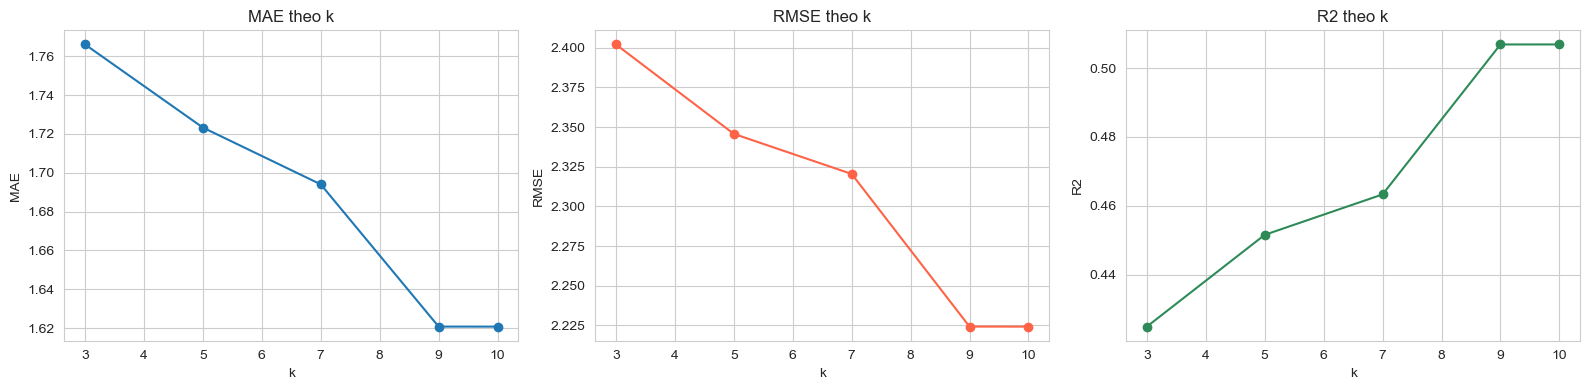

Da luu hinh: 03_feature_selection_kbest_metrics.png


In [ ]:
bảng_plot = bảng_kết_quả.sort_values(by="k")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(bảng_plot["k"], bảng_plot["MAE"], marker="o")
axes[0].set_title("MAE theo k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("MAE")

axes[1].plot(bảng_plot["k"], bảng_plot["RMSE"], marker="o", color="tomato")
axes[1].set_title("RMSE theo k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("RMSE")

axes[2].plot(bảng_plot["k"], bảng_plot["R2"], marker="o", color="seagreen")
axes[2].set_title("R2 theo k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("R2")

plt.tight_layout()
plt.savefig("../../outputs/figures/03_feature_selection_kbest_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
print("Đã lưu hình: 03_feature_selection_kbest_metrics.png")

## 7. Huấn luyện lại với k tốt nhất và xem đặc trưng được chọn

In [ ]:
k_tốt_nhất = int(bảng_kết_quả.iloc[0]["k"])
print("k tốt nhất theo RMSE:", k_tốt_nhất)

mô_hình_tốt_nhất = Pipeline(steps=[
    ("tiền_xử_lý", tiền_xử_lý),
    ("chọn_k", SelectKBest(score_func=f_regression, k=k_tốt_nhất)),
    ("hồi_quy", Ridge(alpha=1.0)),
])

mô_hình_tốt_nhất.fit(X_train, y_train)

# Lấy tên đặc trưng sau tiền xử lý
tên_đặc_trưng_sau_xử_lý = mô_hình_tốt_nhất.named_steps["tiền_xử_lý"].get_feature_names_out()
bộ_lọc = mô_hình_tốt_nhất.named_steps["chọn_k"].get_support()
điểm = mô_hình_tốt_nhất.named_steps["chọn_k"].scores_

bảng_điểm = pd.DataFrame({
    "đặc_trưng": tên_đặc_trưng_sau_xử_lý,
    "điểm_f": điểm,
    "được_chọn": bộ_lọc,
}).sort_values(by="điểm_f", ascending=False)

bảng_điểm.head(15)

k tốt nhất theo RMSE: 10


,dac_trung,diem_f,duoc_chon
6,so__shell_weight,1872.620818,True
1,so__diameter,1377.778890,True
0,so__length,1266.124925,True
2,so__height,1226.148800,True
3,so__whole_weight,1170.191209,True
5,so__viscera_weight,969.346863,True
8,hang_muc__sex_I,620.906204,True
4,so__shucked_weight,603.890504,True
7,hang_muc__sex_F,179.919414,True
9,hang_muc__sex_M,88.096955,True


## 8. Đánh giá trên tập test

In [ ]:
dự_đoán_test = mô_hình_tốt_nhất.predict(X_test)
mae_test = mean_absolute_error(y_test, dự_đoán_test)
rmse_test = np.sqrt(mean_squared_error(y_test, dự_đoán_test))
r2_test = r2_score(y_test, dự_đoán_test)

print("Kết quả trên test:")
print(f"MAE : {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2  : {r2_test:.4f}")

Ket qua tren test:
MAE : 1.5451
RMSE: 2.1457
R2  : 0.5515


## 9. Lưu kết quả

In [ ]:
đường_dẫn_metrics = Path("../../outputs/metrics").resolve()
đường_dẫn_metrics.mkdir(parents=True, exist_ok=True)

bảng_kết_quả.to_csv(đường_dẫn_metrics / "03_kbest_k_comparison.csv", index=False)
bảng_điểm.to_csv(đường_dẫn_metrics / "03_kbest_feature_scores.csv", index=False)

tóm_tắt = {
    "phương_pháp": "select_k_best",
    "k_tốt_nhất": k_tốt_nhất,
    "val_tốt_nhất": bảng_kết_quả.iloc[0].to_dict(),
    "test": {
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R2": r2_test,
    },
}

with open(đường_dẫn_metrics / "03_kbest_summary.json", "w", encoding="utf-8") as f:
    json.dump(tóm_tắt, f, ensure_ascii=False, indent=2)

print("Đã lưu: 03_kbest_k_comparison.csv")
print("Đã lưu: 03_kbest_feature_scores.csv")
print("Đã lưu: 03_kbest_summary.json")

Da luu: 03_kbest_k_comparison.csv
Da luu: 03_kbest_feature_scores.csv
Da luu: 03_kbest_summary.json
